# Figure 3: Decision variable prediction

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd "/app/"

/app


/usr/local/lib/python3.9/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
%run env_aws.py
%run run.py connect

2025-07-14 14:11:47,585::INFO::settings.py::Setting loglevel to INFO
2025-07-14 14:11:47,586::INFO::settings.py::Setting stores to {}
2025-07-14 14:11:47,587::INFO::settings.py::Setting database.misc.schema_prefix to 
2025-07-14 14:11:47,588::INFO::settings.py::Setting database.misc.create_tables to True
2025-07-14 14:11:47,589::INFO::settings.py::Setting enable_python_native_blobs to True
2025-07-14 14:11:47,590::INFO::settings.py::Setting database.host to vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com
2025-07-14 14:11:47,591::INFO::settings.py::Setting database.user to celia
2025-07-14 14:11:47,592::INFO::settings.py::Setting database.password to celia_mathislab
2025-07-14 14:11:47,766::INFO::connection.py::Connected celia@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


Connecting celia@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


2025-07-14 14:11:47,876::INFO::table.py::could not log event in table ~log
2025-07-14 14:11:48,298::INFO::table.py::could not log event in table ~log
2025-07-14 14:11:48,298::INFO::table.py::could not log event in table ~log
2025-07-14 14:11:48,768::INFO::table.py::could not log event in table ~log
2025-07-14 14:11:48,768::INFO::table.py::could not log event in table ~log
2025-07-14 14:11:48,914::INFO::table.py::could not log event in table ~log
2025-07-14 14:11:48,914::INFO::table.py::could not log event in table ~log
2025-07-14 14:11:49,233::INFO::table.py::could not log event in table ~log
2025-07-14 14:11:49,233::INFO::table.py::could not log event in table ~log
2025-07-14 14:11:49,546::INFO::table.py::could not log event in table ~log
2025-07-14 14:11:49,546::INFO::table.py::could not log event in table ~log


In [4]:
from vr4mice.schema.base_analysis import DataFrame
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from vr4mice.analysis import plotting
from base_schemas.schemas.exp import Session
from vr4mice.schema import base_analysis
from vr4mice.analysis.analysis import style
from vr4mice.schema.interpolated_trajectories import InterpolatedTrials
from vr4mice.schema.session_metrics import TrialMetrics
from vr4mice.analysis import analysis
from vr4mice.schema import dlc
from vr4mice.analysis import utils
from vr4mice.analysis import regression

from statsmodels.stats.anova import AnovaRM
from scipy.stats import ttest_rel, ttest_ind
import scipy.stats as stats

style()

save_fig_path = "notebooks/Paper_figures/Figure_output/"

2025-07-14 14:11:49,752::INFO::table.py::could not log event in table ~log
2025-07-14 14:11:49,752::INFO::table.py::could not log event in table ~log
2025-07-14 14:11:49,893::INFO::table.py::could not log event in table ~log
2025-07-14 14:11:49,893::INFO::table.py::could not log event in table ~log


In [5]:
trial_df = (TrialMetrics() * vr4mice.Groups() * vr4mice.Labels() * (vr4mice.Dataset() & 'session_label = "ar_discrim_occluders"')).fetch(as_dict=True)
trial_df =  pd.concat([pd.DataFrame(x) for x in trial_df])
# Exclude sessions that were not in the list
trial_df, reward_table = utils.dual_occluder_inclusion_criteria(trial_df, return_excluded=False)
# Create list of included datasets
mouse_list = trial_df.dataset.unique()
trial_df["mouse_name"] = trial_df.dataset.str.split("_").str [0]

Excluded datasets:  ['J731_2024-12-06_1' 'J731_2024-12-04_1' 'J729_2024-11-29_1'
 '31728_2025-03-06_1' '31728_2025-03-05_1']


In [6]:
# This takes a while to fetch because we need to fetch data for all trials (4 min 20 secs) 
dataset_list = []
for d in mouse_list:
    print(d)
    try:
        if len(InterpolatedTrials() & f'dataset = "{d}"') > 0:
            dataset_list.append(pd.DataFrame((InterpolatedTrials() & f'dataset = "{d}"').fetch(as_dict=True)[0]))
        else:
            print("dataset missing")
    except Exception as err:
        print(err, " dataset missing")
interpolated_df = pd.concat(dataset_list)
interpolated_df ["mouse_name"] = interpolated_df.dataset.str.split("_").str [0]

Pheasant_2024-08-21_1
Pheasant_2024-08-20_1
Pheasant_2024-08-19_1
Pheasant_2024-08-16_1
Pheasant_2024-08-15_2
Oribi_2024-08-22_1
Oribi_2024-08-21_1
Oribi_2024-08-20_1
Oribi_2024-08-19_1
Oribi_2024-08-16_1
Nightingale_2024-08-14_1
Nightingale_2024-08-13_1
Nightingale_2024-08-12_1
Nightingale_2024-08-11_1
Nightingale_2024-08-10_1
Lemming_2024-08-13_1
Lemming_2024-08-12_1
Lemming_2024-08-11_1
Lemming_2024-08-10_1
Kiwi_2024-08-14_1
Kiwi_2024-08-13_1
Kiwi_2024-08-12_2
Kiwi_2024-08-11_4
Kiwi_2024-08-10_2
Jacana_2024-08-19_1
Jacana_2024-08-16_1
Jacana_2024-08-15_1
Jacana_2024-08-14_1
Jacana_2024-08-13_1
J731_2024-12-09_1
J731_2024-12-05_1
J729_2024-12-10_1
J729_2024-12-04_1
J729_2024-12-03_1
J729_2024-12-02_1
J729_2024-12-01_1
J729_2024-11-30_1
31728_2025-03-21_1
31728_2025-03-20_1
31728_2025-03-07_1
31726_2025-03-21_1
31726_2025-03-20_1
31726_2025-03-19_1
31726_2025-03-18_1


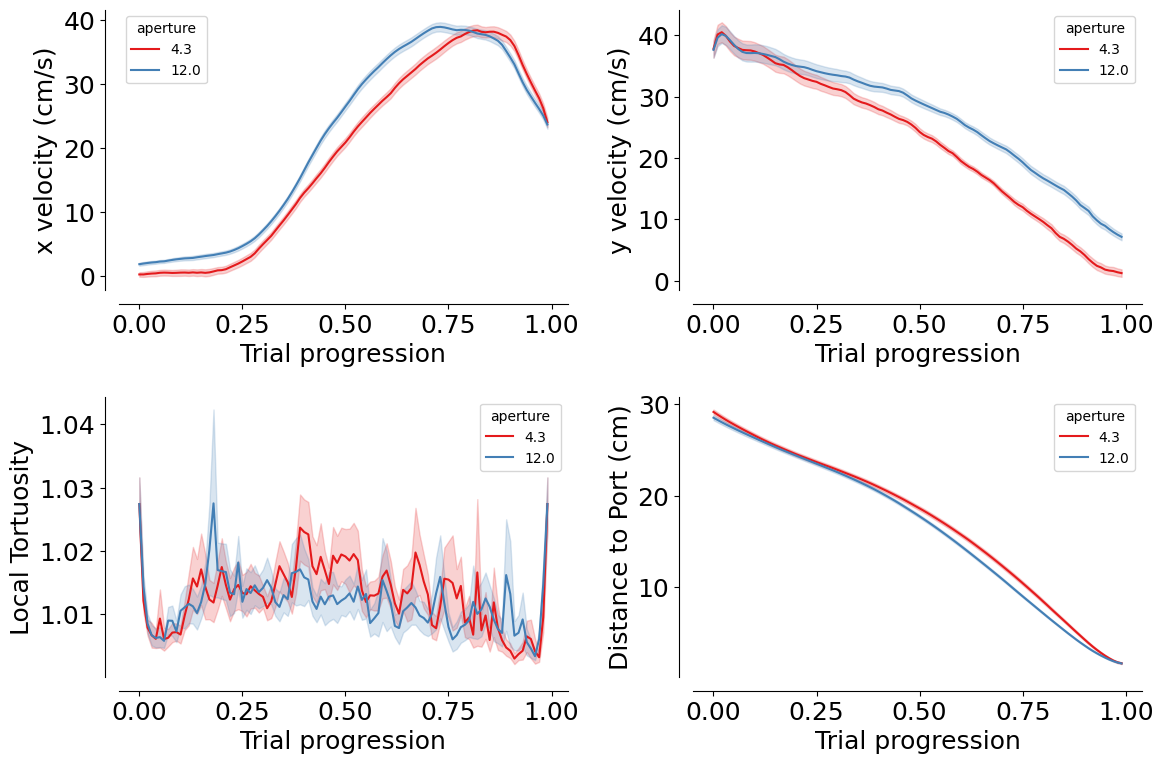

In [7]:
mean_mouse = interpolated_df.groupby(
    ["dataset", "aperture", "trial_length"], as_index=False
).mean(numeric_only=True)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax = ax.flatten()

for (i, label), label_str in zip(enumerate(
    ["velocity_x_fliped", "velocity_y", "local_tortuosity", "distance_to_choice"]
), ["x velocity (cm/s)", "y velocity (cm/s)", "Local Tortuosity", "Distance to Port (cm)"]):
    sns.lineplot(
        data=mean_mouse,
        x="trial_length",
        y=label,
        palette=(
            plotting.colors_aperture[:2]
            if len(mean_mouse.aperture.unique()) == 2
            else "viridis"
        ),
        hue="aperture",
        errorbar="se",
        ax=ax[i],
    )
    ax[i].set_ylabel(label_str)
    ax[i].set_xlabel("Trial progression")
    sns.despine(ax=ax[i], offset=10)
    
plt.tight_layout(pad=2)
plt.savefig(save_fig_path + "figure3_velocity_tortuosity_distance.svg", bbox_inches="tight", transparent=True)

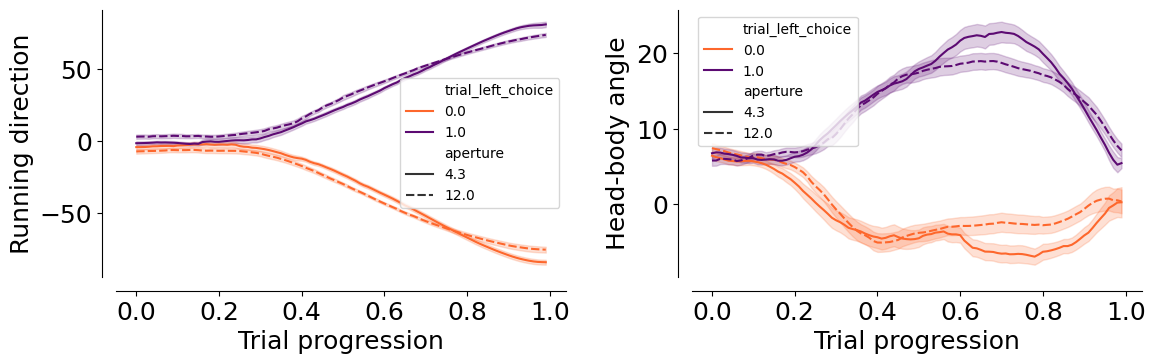

In [8]:
mean_mouse = interpolated_df.groupby(
    ["dataset", "aperture", "trial_left_choice", "trial_length"], as_index=False
).mean(numeric_only=True)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax = ax.flatten()

for (i, label), label_str in zip(enumerate(["heading_dir", "head_angle"]), 
                                 ["Running direction", "Head-body angle"]):
    sns.lineplot(
        data=mean_mouse,
        x="trial_length",
        y=label,
        palette=plotting.colors_choice[::-1]
        if len(mean_mouse.aperture.unique()) == 2
        else "viridis",
        hue="trial_left_choice"
        if len(mean_mouse.aperture.unique()) == 2
        else "aperture",
        style=(
            "aperture"
            if len(mean_mouse.aperture.unique()) == 2
            else "trial_left_choice"
        ),
        errorbar="se",
        ax=ax[i],
    )
    ax[i].set_ylabel(label_str)
    ax[i].set_xlabel("Trial progression")
    sns.despine(ax=ax[i], offset=10)


plt.tight_layout(pad=2)
plt.savefig(save_fig_path + "figure3_heading_dir_head_angle.svg", bbox_inches="tight", transparent=True)

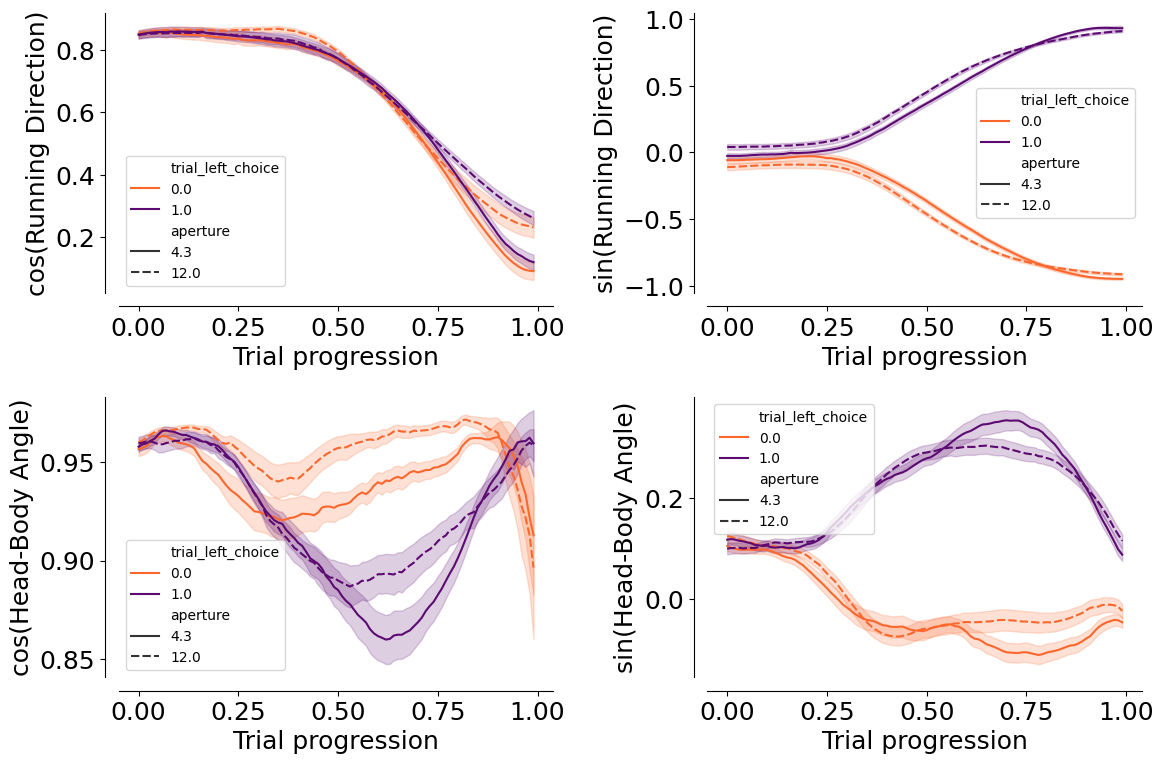

In [9]:
mean_mouse = interpolated_df.groupby(
    ["dataset", "aperture", "trial_left_choice", "trial_length"], as_index=False
).mean(numeric_only=True)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax = ax.flatten()

for (i, label), label_str in zip(enumerate(
    ["heading_dir_cos", "heading_dir_sin", "head_angle_cos", "head_angle_sin"]
), ["cos(Running Direction)", "sin(Running Direction)", "cos(Head-Body Angle)", "sin(Head-Body Angle)"]):
    sns.lineplot(
        data=mean_mouse,
        x="trial_length",
        y=label,
        palette=plotting.colors_choice[::-1]
        if len(mean_mouse.aperture.unique()) == 2
        else "viridis",
        hue="trial_left_choice"
        if len(mean_mouse.aperture.unique()) == 2
        else "aperture",
        style=(
            "aperture"
            if len(mean_mouse.aperture.unique()) == 2
            else "trial_left_choice"
        ),
        errorbar="se",
        ax=ax[i],
    )
    ax[i].set_ylabel(label_str)
    ax[i].set_xlabel("Trial progression")
    sns.despine(ax=ax[i], offset=10)


plt.tight_layout(pad=2)
plt.savefig(save_fig_path + "figure3_heading_dir_head_angle_cos_sin.svg", bbox_inches="tight", transparent=True)

In [10]:
box_df = base_analysis.BoxDataFrame().get_data(key={"dataset": "Pheasant_2024-08-15_2"})

In [11]:
model_labels = regression.model_labels 

In [27]:
interpolated_df["aperture"] = interpolated_df["aperture"].astype(float)

df_model, coef = regression.predict_decision(
    df=interpolated_df, label=model_labels, per_mouse=True
)

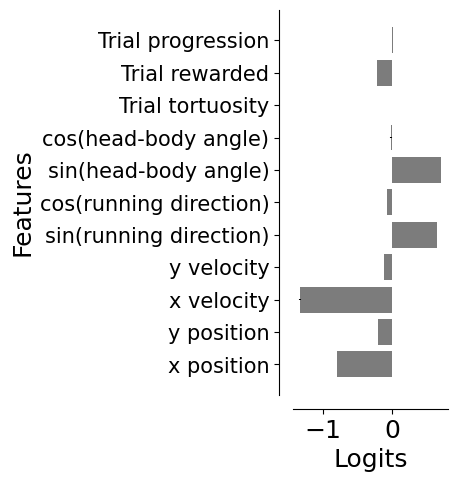

In [30]:
# Logits of the regression
import scipy.stats
fig, ax = plt.subplots(1, 1, figsize=(2, 5))
ax.barh(
    regression.model_labels,
    np.mean(coef[:, 1:], axis=0),
    yerr=scipy.stats.sem(coef[:, 1:], axis=0),
    color="#7C7C7C",
)
sns.despine(offset=10, ax=ax)

ax.set_yticks(np.arange(len(regression.model_labels)))
ax.set_yticklabels(regression.clean_model_labels, rotation=0, ha="right", fontsize=15)
ax.set_xlabel("Logits")
ax.set_ylabel("Features")

plt.savefig(save_fig_path + "figure3_dual_occluder_model_logits.svg", transparent=False)

Oribi_2024-08-16_1


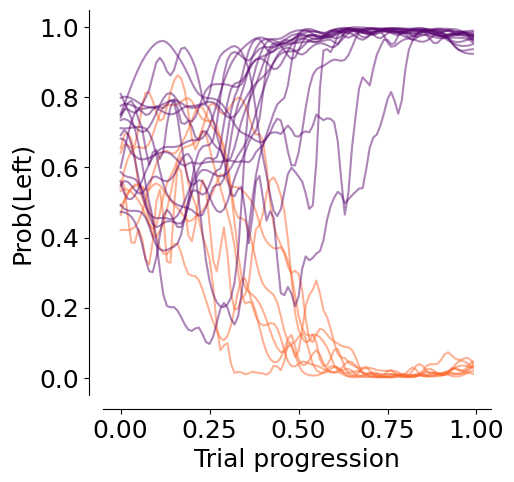

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

group = df_model[(df_model.dataset == "Kiwi_2024-08-14_1")]
print(df_model.dataset.unique()[9])

trials = [
    94,
    15,
    66,
    170,
    224,
    195,
    56,
    203,
    88,
    239,
    113,
    91,
    186,
    248,
    109,
    164,
    188,
    60,
    229,
    182,
    156,
    197,
    52,
    45,
]  # 110, 156, 190,  22, 210,  24,  51,  78,
# 239,  97,  24, 176, 168, 184, 123, 156]

group = group[group.trial.isin(np.array(trials))]
sns.lineplot(
    data=group,
    x="trial_length",
    y="proba_left",
    hue="trial_left_choice",
    errorbar=None,
    estimator=None,
    units="trial",
    palette=plotting.colors_choice[::-1],
    sort=False,
    alpha=0.5,
    ax=ax,
)
ax.set_ylabel("Prob(Left)")
ax.set_xlabel("Trial progression")
ax.legend([], [], frameon=False)
sns.despine(offset=10)

plt.savefig(
    save_fig_path + "figure3_dual_occluder_dynamic_decision_variable.svg",
    transparent=True,
)

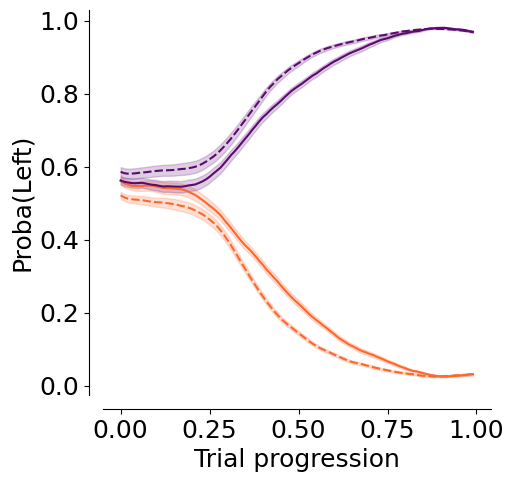

In [15]:
df_model_mean =  df_model.groupby(["dataset", "aperture", "trial_left_choice", "trial_length"], as_index=False).mean()
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
sns.lineplot(
    data=df_model_mean,
    x="trial_length",
    y="proba_left",
    hue="trial_left_choice",
    style="aperture",
    palette=plotting.colors_choice[::-1],
    sort=False,
    alpha=1,
    ax=ax,
    errorbar="se"
)
ax.set_ylabel("Proba(Left)")
ax.set_xlabel("Trial progression")
ax.legend([], [], frameon=False)
sns.despine(offset=10)
plt.savefig(
    save_fig_path + "figure3_dual_occluder_dynamic_decision_variable_avg.svg",
    transparent=True,
)

In [16]:
df_model_mean =  df_model.groupby(["dataset", "aperture", "trial_length"], as_index=False).mean()

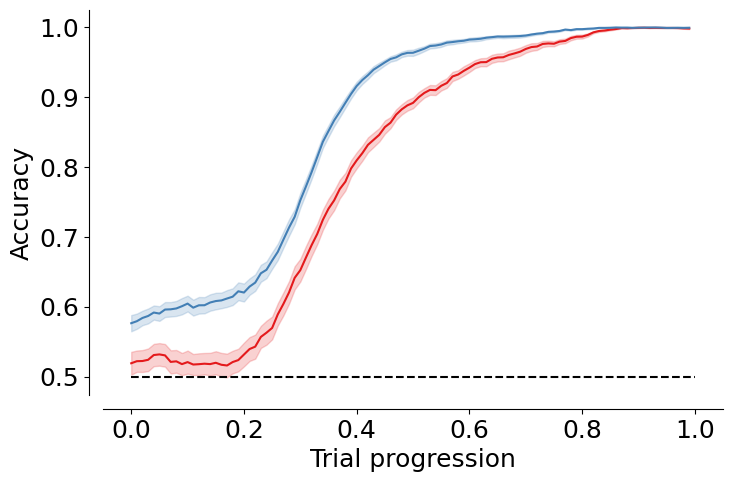

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
sns.lineplot(
    data=df_model_mean,
    x="trial_length",
    y="accuracy",
    hue="aperture",
    palette=plotting.colors_aperture,
    sort=False,
    alpha=1,
    ax=ax,
    errorbar="se"
)
ax.hlines(0.5, 0, 1, color="black", linestyle="--")

ax.set_ylabel("Accuracy")
ax.set_xlabel("Trial progression")
ax.legend([], [], frameon=False)
sns.despine(offset=10)

plt.savefig(
    save_fig_path + "figure3_dual_occluder_model_accuracy.svg", transparent=True
)

In [18]:
df_model["trial_length_bin"] = pd.cut(
    df_model["trial_length"], bins=50
)  # Adjust bins as needed
df_anova = df_model.groupby(
    ["dataset", "aperture", "trial_length_bin"], as_index=False
)["accuracy"].mean()

print(
    AnovaRM(
        data=df_anova,
        depvar="accuracy",
        subject="dataset",
        within=["aperture", "trial_length_bin"],
    ).fit()
)

                           Anova
                           F Value   Num DF   Den DF  Pr > F
------------------------------------------------------------
aperture                    54.4416  1.0000   43.0000 0.0000
trial_length_bin          1074.8602 49.0000 2107.0000 0.0000
aperture:trial_length_bin   15.9972 49.0000 2107.0000 0.0000



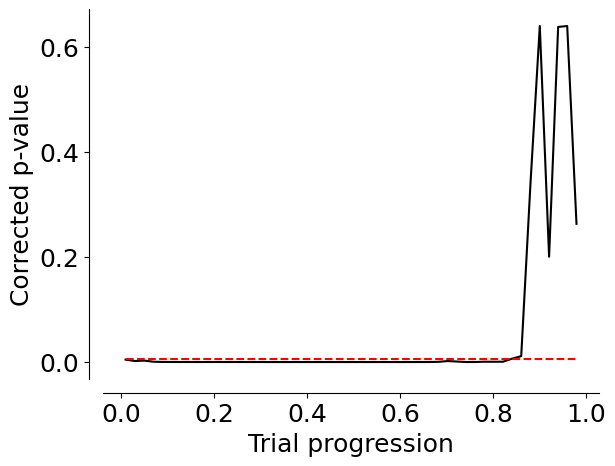

In [19]:
p_values = []
for i in df_anova.trial_length_bin.unique():
    section = df_anova[df_anova.trial_length_bin == i]
    t = ttest_ind(
        section[section.aperture == section.aperture.unique()[0]].accuracy,
        section[section.aperture == section.aperture.unique()[1]].accuracy,
    )
    p_values.append(pd.DataFrame({"segment": i, "p_value": t.pvalue}, index=[0]))

p_value_df = pd.concat(p_values)
p_value_df["p_value_corr"] = stats.false_discovery_control(p_value_df.p_value)

# Convert interval bins to numeric midpoints
p_value_df["segment"] = p_value_df["segment"].apply(lambda x: x.mid)

plt.plot(p_value_df.segment, p_value_df.p_value_corr, c="k")

plt.hlines(
    0.005,
    xmin=p_value_df.segment.min(),
    xmax=p_value_df.segment.max(),
    color="red",
    linestyle="dashed",
)

plt.xlabel("Trial progression")
plt.ylabel("Corrected p-value")

sns.despine(offset=10)
plt.savefig(
    save_fig_path + "figure3_dual_occluder_model_accuracy_pvalue.svg", transparent=True
)

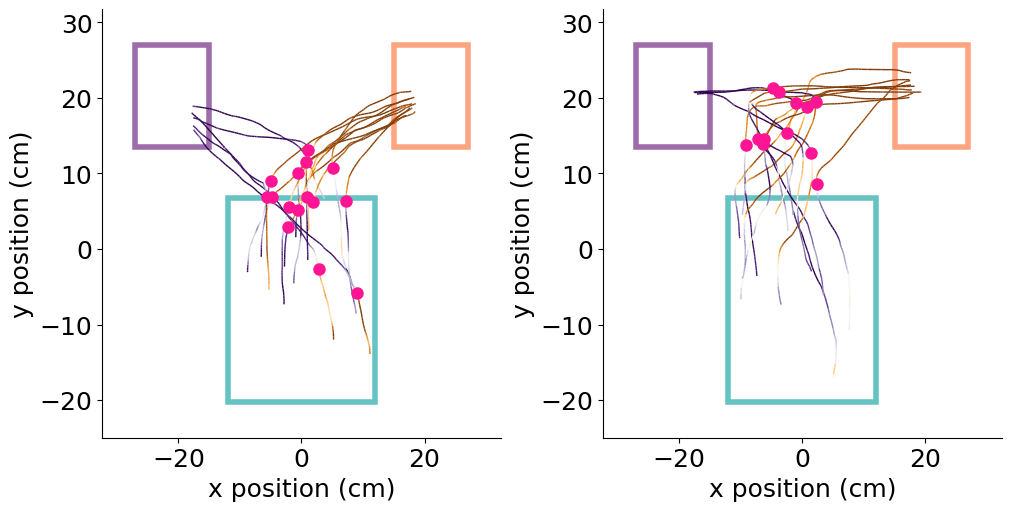

In [20]:
df_model["session"] = df_model["dataset"]
df_model["trial_L_choice"] = df_model["trial_left_choice"]
decision_points = regression.find_decision_point(df_model, threshold_uncertainty=0.3)
fig, ax = plt.subplots(
    1, len(df_model.aperture.unique()), figsize=(10, 5), constrained_layout=True
)

decision_color = "deeppink"
session_to_plot = "Pheasant_2024-08-15_2"
box_df = base_analysis.BoxDataFrame().get_data(key={"dataset": "Pheasant_2024-08-15_2"})

trials = [44, 45, 19, 62, 61, 45, 85, 41, 43, 41, 50, 75, 24, 69, 84, 74, 10] + [
    63,
    30,
    78,
    47,
    33,
    5,
    17,
    9,
    47,
    30,
    99,
    11,
    12,
    15,
]


for i, aperture in enumerate(df_model.aperture.unique()):
    regression.plot_decision_points_on_trajectory(
        df_model[
            (df_model.dataset == session_to_plot) & (df_model.aperture == aperture)
        ],
        box_df,
        decision_point=decision_points[
            (decision_points.dataset == session_to_plot)
            & (decision_points.aperture == aperture)
        ],
        color=decision_color,
        trials=trials,
        ax=ax[i],
    )
    ax[i].set_xlabel("x position (cm)")
    ax[i].set_ylabel("y position (cm)")
plt.savefig(
    save_fig_path + "figure3_dual_occluder_decision_points_trajectories.svg",
    transparent=True,
)

2025-07-14 14:18:51,235::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-14 14:18:51,235::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-14 14:18:51,248::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-14 14:18:51,248::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-14 14:18:51,327::INFO::category.py::Using categorical un

12.0-4.3: TtestResult(statistic=-6.429940435928281, pvalue=8.656775516122754e-08, df=43)


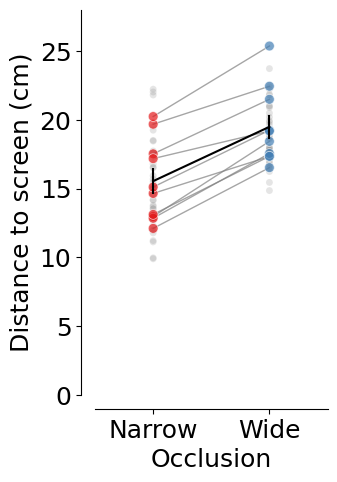

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(3, 5))
stats = plotting.pairplot_average_decision_point(
    decision_points,
    label_parameter="y",
    ax=ax,
    cmap=plotting.colors_aperture,
    per_mouse=True,
)
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(0, 28)
ax.set_xlabel("Occlusion")
ax.set_xticks([0, 1], ["Narrow", "Wide"])
ax.set_ylabel("Distance to screen (cm)")
sns.despine(offset=10)
plt.legend([], [], frameon=False)

plt.savefig(
    save_fig_path + "figure3_dual_occluder_decision_points_distance.svg",
    transparent=True,
)

In [22]:
decision_points["lab_id"] = 0
for dataset_name in mouse_list:
    # Fetch lab_id for each dataset
    decision_points.loc[decision_points.dataset==dataset_name, "lab_id"] = ((vr4mice.Collab() & f'dataset = "{dataset_name}"') * vr4mice.Labs()).fetch("lab")[0]

2025-07-14 14:18:55,743::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-14 14:18:55,743::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-14 14:18:55,750::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-14 14:18:55,750::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-14 14:18:55,807::INFO::category.py::Using categorical un

12.0-4.3: TtestResult(statistic=-12.611717220496418, pvalue=4.830872492140344e-16, df=43)


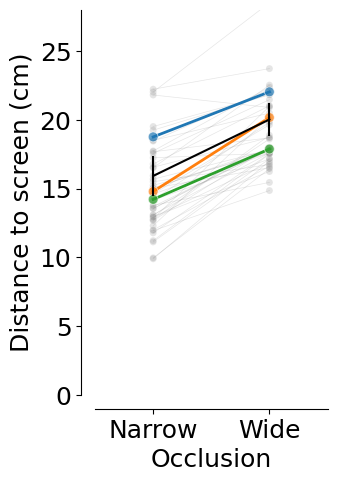

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(3, 5))
stats = plotting.pairplot_average_decision_point(
    decision_points,
    label_parameter="y",
    ax=ax,
    cmap=plotting.colors_aperture,
    per_lab=True,
)
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(0, 28)
ax.set_xlabel("Occlusion")
ax.set_xticks([0, 1], ["Narrow", "Wide"])
ax.set_ylabel("Distance to screen (cm)")
sns.despine(offset=10)
plt.legend([], [], frameon=False)

plt.savefig(
    save_fig_path + "figure3_dual_occluder_decision_points_distance_per_lab.svg",
    transparent=True,
)

In [24]:
decision_points = decision_points.groupby(["dataset", "aperture"], as_index=False)[
    "y"
].mean()
anova_rm = AnovaRM(decision_points, depvar="y", subject="dataset", within=["aperture"])

anova_results = anova_rm.fit()
anova_table = anova_results.summary()
print(anova_table)

                 Anova
         F Value  Num DF  Den DF Pr > F
---------------------------------------
aperture 159.0554 1.0000 43.0000 0.0000



In [25]:
decision_points.groupby("aperture").y.mean(), decision_points.groupby("aperture").y.sem()

(aperture
 4.3     11.959052
 12.0     8.045967
 Name: y, dtype: float64,
 aperture
 4.3     0.461924
 12.0    0.387437
 Name: y, dtype: float64)